# Week 2 — Topic Modeling & Department Categorization
## AI-Driven Citizen Grievance & Sentiment Analysis System

**Objective:** Convert cleaned text into numerical vectors using TF-IDF and train supervised classification models to automatically route complaints to the correct government department.

**Roadmap for this notebook:**
1. Load preprocessed data from Week 1
2. Feature Engineering — TF-IDF Vectorization
3. Train/Test Split & Label Encoding
4. Baseline Models — Naive Bayes & Logistic Regression
5. Advanced Models — SVM & Random Forest
6. Cross-Validation & Hyperparameter Tuning
7. Model Evaluation & Confusion Matrix
8. Prediction Pipeline Demo
9. Save Models for Week 3

## Step 1: Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn — Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Sklearn — Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Sklearn — Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


## Step 2: Load Preprocessed Data from Week 1

> Upload `processed_grievances.csv` (saved at the end of Week 1) to your Colab session, or use the synthetic generator below if it is not available.

In [3]:
import os

if os.path.exists('processed_grievances.csv'):
    df = pd.read_csv('processed_grievances.csv')
    print(f'✅ Loaded Week 1 data — Shape: {df.shape}')
else:
    print('⚠️  processed_grievances.csv not found. Generating synthetic dataset...')

    import random, re, spacy
    import nltk
    from nltk.corpus import stopwords
    from tqdm import tqdm

    nltk.download('stopwords', quiet=True)
    !python -m spacy download en_core_web_sm -q
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    STOPWORDS = set(stopwords.words('english'))

    random.seed(42)
    templates = {
        'Water Supply':    [
            'Water supply is completely cut off in our area for {n} days.',
            'The tap water has a foul smell and brown color, undrinkable.',
            'Low water pressure makes it impossible to shower or cook.',
            'No running water since {n} days. Residents are struggling.',
            'Water leakage from the main pipeline is wasting thousands of liters.',
            'Contaminated water supply is causing illness in the neighborhood.',
            'Water connection has been disconnected without prior notice.',
            'Water tanker has not arrived for {n} days despite repeated requests.',
        ],
        'Electricity':     [
            'Power outage for {n} hours with no communication from the utility.',
            'Frequent voltage fluctuations are damaging home appliances.',
            'Street lights in sector {n} have not been working for weeks.',
            'Electric pole is dangerously tilted and could collapse any time.',
            'Electricity bill is extremely high despite low consumption this month.',
            'Transformer has blown in our colony. No power since {n} days.',
            'Live wire is exposed near the playground, risk to children.',
            'Power cut during exam season is affecting students badly.',
        ],
        'Roads & Transport':[
            'Massive potholes on main road have damaged several vehicles.',
            'The road has not been repaired despite {n} complaints filed.',
            'No footpath available. Pedestrians are forced to walk on the road.',
            'Bus route {n} has been cancelled without any announcement.',
            'Road digging completed but surface is not restored. Dangerous for bikes.',
            'Traffic signal at the main junction is not functioning.',
            'Overflowing drain is blocking the road and causing waterlogging.',
            'No speed breaker near the school zone. Accidents are frequent.',
        ],
        'Sanitation':      [
            'Garbage has not been collected for {n} days. Stench is unbearable.',
            'Open drain next to residential area is a major health hazard.',
            'Sanitation workers are not cleaning the public toilets regularly.',
            'Waste dumped near park is attracting rats and stray animals.',
            'Sewage overflow on the main street. Urgent action required.',
            'Community dustbin is overflowing and spreading disease.',
            'Dead animals not removed from the street for {n} days.',
            'Illegal dumping of construction debris on public land.',
        ],
        'Public Safety':   [
            'Street lights are not working. Area is unsafe at night.',
            'Frequent theft incidents in sector {n}. Need police patrol.',
            'Stray dogs are attacking children near the school.',
            'Loud noise and anti-social activity near residential colony.',
            'Illegal construction blocking the emergency access road.',
            'No CCTV cameras installed despite repeated demands.',
            'Drug peddling activity openly happening near the park.',
            'Speeding vehicles are a daily danger on the inner road.',
        ],
    }

    rows = []
    for dept, phrases in templates.items():
        for _ in range(250):
            phrase = random.choice(phrases).format(n=random.randint(2, 15))
            rows.append({'narrative': phrase, 'product': dept})

    df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'[^a-z\s]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    df['cleaned_text'] = df['narrative'].apply(clean_text)

    processed = []
    for doc in tqdm(nlp.pipe(df['cleaned_text'], batch_size=500), total=len(df)):
        tokens = [t.lemma_ for t in doc if t.text not in STOPWORDS and len(t.text) > 2]
        processed.append(' '.join(tokens))
    df['processed_text'] = processed

    df.to_csv('processed_grievances.csv', index=False)
    print(f'✅ Synthetic dataset generated and saved — Shape: {df.shape}')

print(f'\nColumns: {list(df.columns)}')
print(f'Departments: {df["product"].unique()}')
print(f'Class distribution:\n{df["product"].value_counts()}')

⚠️  processed_grievances.csv not found. Generating synthetic dataset...
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


100%|██████████| 1250/1250 [00:01<00:00, 780.54it/s]

✅ Synthetic dataset generated and saved — Shape: (1250, 4)

Columns: ['narrative', 'product', 'cleaned_text', 'processed_text']
Departments: ['Roads & Transport' 'Public Safety' 'Electricity' 'Sanitation'
 'Water Supply']
Class distribution:
product
Roads & Transport    250
Public Safety        250
Electricity          250
Sanitation           250
Water Supply         250
Name: count, dtype: int64


## Step 3: Feature Engineering — TF-IDF Vectorization

**TF-IDF** (Term Frequency–Inverse Document Frequency) converts raw text into a numerical matrix where each word gets a weight based on:
- **TF** — how often it appears in a document
- **IDF** — how rare it is across all documents (penalizes common words)

We experiment with both **unigrams** and **bigrams** to capture phrases like `"water supply"` or `"power outage"`.

In [4]:
# Encode target labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['product'])

print('Label Encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

X = df['processed_text']
y = df['label']

Label Encoding:
  0 → Electricity
  1 → Public Safety
  2 → Roads & Transport
  3 → Sanitation
  4 → Water Supply


In [5]:
# Train/Test Split — Stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Train class distribution:\n{pd.Series(y_train).value_counts().sort_index()}')

Train size: 1000 | Test size: 250
Train class distribution:
label
0    200
1    200
2    200
3    200
4    200
Name: count, dtype: int64


In [6]:
# TF-IDF Vectorizer — Unigrams + Bigrams
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # capture unigrams and bigrams
    max_features=10000,   # top 10k features
    sublinear_tf=True,    # apply log normalization to TF
    min_df=2,             # ignore terms appearing in fewer than 2 docs
    strip_accents='unicode',
    analyzer='word'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')

TF-IDF matrix shape (train): (1000, 392)
TF-IDF matrix shape (test) : (250, 392)


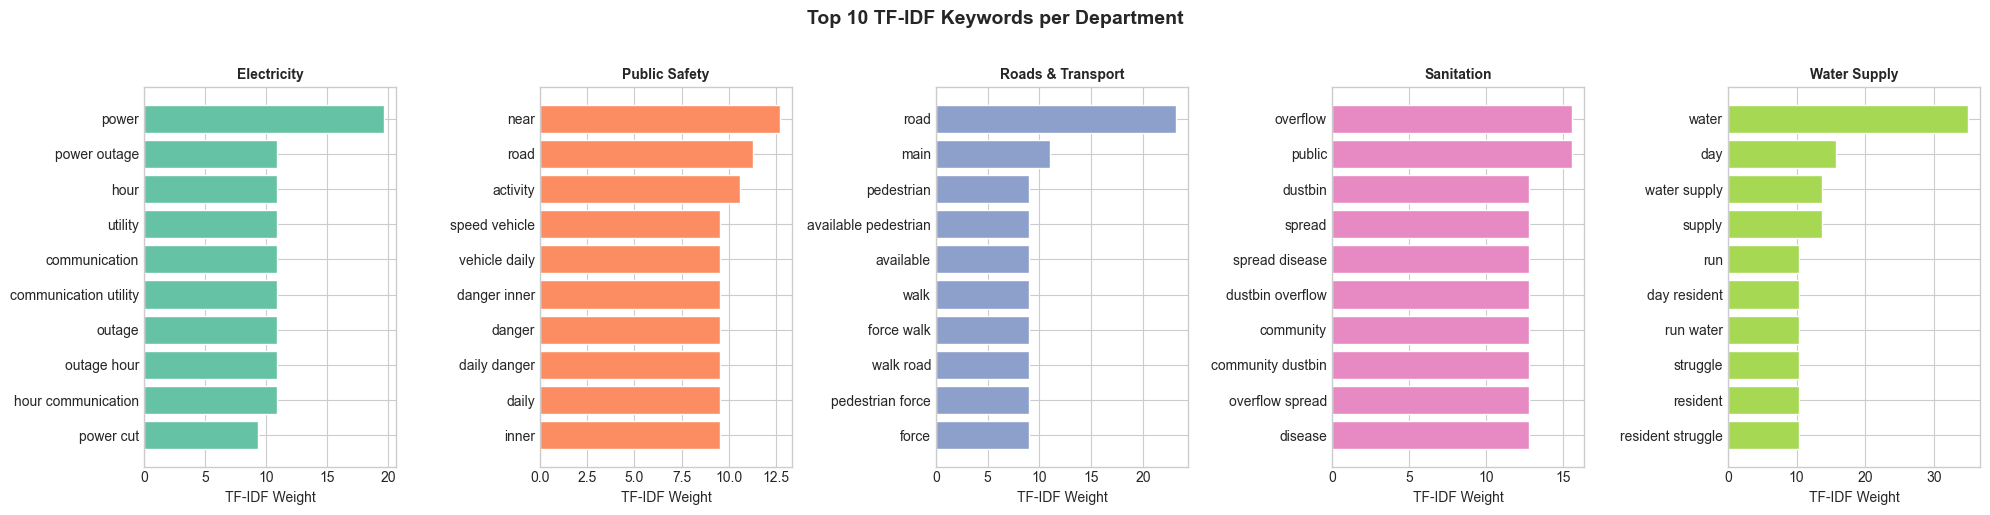

✅ Saved: tfidf_top_features.png


In [7]:
# Visualize top TF-IDF features per department
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, len(le.classes_), figsize=(20, 5))
colors = sns.color_palette('Set2', len(le.classes_))

for i, (cls, ax, color) in enumerate(zip(le.classes_, axes, colors)):
    # Get indices of samples belonging to this class in training set
    indices = [j for j, label in enumerate(y_train) if label == i]
    if not indices:
        continue
    # Sum TF-IDF weights for this class
    class_tfidf = X_train_tfidf[indices].sum(axis=0).A1
    top_idx = class_tfidf.argsort()[-10:][::-1]
    top_words = [feature_names[k] for k in top_idx]
    top_scores = [class_tfidf[k] for k in top_idx]

    ax.barh(top_words[::-1], top_scores[::-1], color=color, edgecolor='white')
    ax.set_title(f'{cls}', fontsize=10, fontweight='bold')
    ax.set_xlabel('TF-IDF Weight')

plt.suptitle('Top 10 TF-IDF Keywords per Department', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tfidf_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: tfidf_top_features.png')

## Step 4: Baseline Models

We start with fast, interpretable baselines before moving to more complex models.

In [8]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, label_names):
    """Train, predict, and return a results dictionary."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc   = accuracy_score(y_te, y_pred)
    macro = f1_score(y_te, y_pred, average='macro')
    weighted = f1_score(y_te, y_pred, average='weighted')

    print(f'\n{'='*55}')
    print(f'  Model: {model_name}')
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Macro F1-Score  : {macro:.4f}')
    print(f'  Weighted F1     : {weighted:.4f}')
    print(f'{'='*55}')
    print(classification_report(y_te, y_pred, target_names=label_names))

    return {
        'model_name': model_name,
        'model_obj': model,
        'y_pred': y_pred,
        'accuracy': acc,
        'macro_f1': macro,
        'weighted_f1': weighted
    }

LABELS = le.classes_.tolist()
results = []